# 03. Очистка real-данных, маски голов и режимы съёмки

очистка → FT-пулы → эмпирические режимы → исправление переставленных λ1/λ2.

In [1]:
from pathlib import Path
import os
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "src").exists():
    raise RuntimeError("неверный путь.")

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from project_paths import *
ensure_project_directories()

print("Project root:", PROJECT_ROOT)

Project root: D:\Users\user\Desktop\DS_XRD_project


In [ ]:
import subprocess

def run_script(script_name, *args):

    # Run one reproducible pipeline stage and stream its output.
    
    command = [sys.executable, str(PROJECT_ROOT / "src" / script_name), *map(str, args)]
    print("Running:", " ".join(command))
    subprocess.run(command, cwd=PROJECT_ROOT, check=True)

## Шаг 1. Очистка, дубликаты и параметры угловой сетки

In [3]:
run_script("step1_clean_and_masks.py")

Running: d:\Dev\envs\study\python.exe D:\Users\user\Desktop\DS_XRD_project\src\step1_clean_and_masks.py


## Шаг 2. Маски целевых голов и fine-tuning pools

In [4]:
run_script("step2_ft_pool.py")

Running: d:\Dev\envs\study\python.exe D:\Users\user\Desktop\DS_XRD_project\src\step2_ft_pool.py


## Шаг 3. Частоты экспериментальных режимов

In [5]:
run_script("step3_modes.py")

Running: d:\Dev\envs\study\python.exe D:\Users\user\Desktop\DS_XRD_project\src\step3_modes.py


## Шаг 4. Нормализация порядка Kα1/Kα2

In [6]:
run_script("step4_fix_wavelengths.py")
run_script("check_wavelengths.py")

Running: d:\Dev\envs\study\python.exe D:\Users\user\Desktop\DS_XRD_project\src\step4_fix_wavelengths.py
Running: d:\Dev\envs\study\python.exe D:\Users\user\Desktop\DS_XRD_project\src\check_wavelengths.py


## Наглядное сравнение режимов

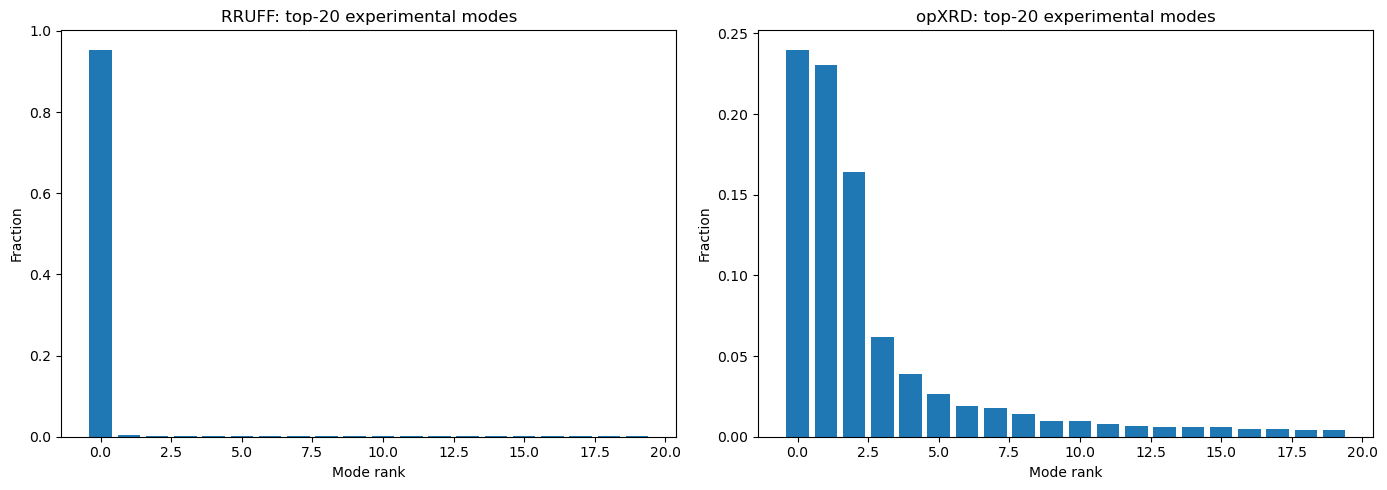

In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

modes_r = pd.read_csv(OUTPUTS_DIR / "modes_rruff.csv")
modes_o = pd.read_csv(OUTPUTS_DIR / "modes_opxrd.csv")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(range(min(20, len(modes_r))), modes_r.head(20)["fraction_all"])
axes[0].set_title("RRUFF: top-20 experimental modes")
axes[1].bar(range(min(20, len(modes_o))), modes_o.head(20)["fraction_all"])
axes[1].set_title("opXRD: top-20 experimental modes")
for ax in axes:
    ax.set_xlabel("Mode rank")
    ax.set_ylabel("Fraction")
plt.tight_layout()
target = FIGURES_DIR / "03_real_pipeline_modes.png"
plt.savefig(target, dpi=160, bbox_inches="tight")
plt.show()

## Вывод

Созданы очищенные real-таблицы, FT-пулы и распределения режимов для генератора.